<a href="https://colab.research.google.com/github/amrita13/TacticalReadinessFOB/blob/main/ScenariospecificDL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

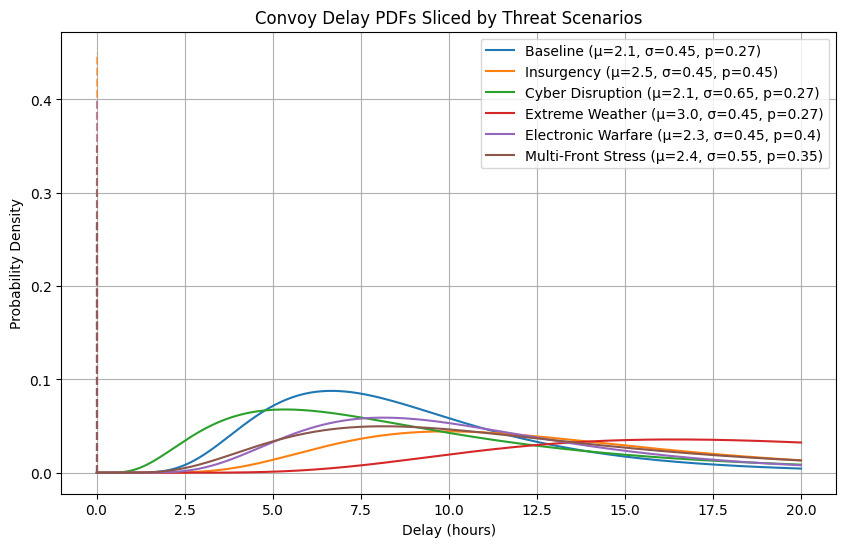

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# ============================================================
# Convoy Delay Mixture Distribution
# ------------------------------------------------------------
# Each scenario is modeled as a mixture of:
#   - Lognormal(μ, σ): continuous convoy delay times
#   - Bernoulli(p): probability mass at zero (disruption event)
#
# Parameters:
#   μ (mu): mean of lognormal in log-space
#   σ (sigma): standard deviation in log-space
#   p: probability of zero delay (disruption)
#
# Threat scenarios adjust μ, σ, and p to reflect operational stress.
# ============================================================

scenarios = {
    # Baseline: natural convoy variability + occasional disruption
    "Baseline": {"mu": 2.1, "sigma": 0.45, "p": 0.27},

    # Insurgency: ambush/IEDs increase disruption probability and mean delay
    "Insurgency": {"mu": 2.5, "sigma": 0.45, "p": 0.45},

    # Cyber disruption: communication breakdown broadens variance (more unpredictable delays)
    "Cyber Disruption": {"mu": 2.1, "sigma": 0.65, "p": 0.27},

    # Extreme weather: terrain/floods increase mean delay (convoys consistently slower)
    "Extreme Weather": {"mu": 3.0, "sigma": 0.45, "p": 0.27},

    # Electronic warfare: jamming increases disruption probability + moderate delay shift
    "Electronic Warfare": {"mu": 2.3, "sigma": 0.45, "p": 0.40},

    # Multi-front stress: simultaneous threats increase both mean and variance
    "Multi-Front Stress": {"mu": 2.4, "sigma": 0.55, "p": 0.35}
}

# Range of delay values (hours)
x = np.linspace(0.01, 20, 500)

plt.figure(figsize=(10, 6))
for name, params in scenarios.items():
    mu, sigma, p = params["mu"], params["sigma"], params["p"]

    # Continuous lognormal PDF scaled by (1-p)
    pdf = (1 - p) * lognorm.pdf(x, s=sigma, scale=np.exp(mu))

    # Plot the continuous curve
    plt.plot(x, pdf, label=f"{name} (μ={mu}, σ={sigma}, p={p})")

    # Plot Bernoulli spike at zero (probability mass of disruption)
    plt.vlines(0, 0, p, colors=plt.gca().lines[-1].get_color(),
               linestyles="dashed", alpha=0.6)

plt.title("Convoy Delay PDFs Sliced by Threat Scenarios")
plt.xlabel("Delay (hours)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)
plt.show()